In [ ]:
!nvidia-smi

Mon Aug 17 08:45:15 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   46C    P8             11W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [ ]:
!pip install gTTS -q

from gtts import gTTS
from IPython.display import Audio

text = "నా పంట ఆకులపై మచ్చలు కనిపిస్తున్నాయి"  # "There are spots appearing on my crop leaves"
tts = gTTS(text=text, lang='te')
tts.save("test_telugu.mp3")

Audio("test_telugu.mp3")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 98.2/98.2 kB 7.0 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
huggingface-hub 1.23.0 requires click<9.0.0,>=8.4.2, but you have click 8.1.8 which is incompatible.
wandb 0.28.0 requires click>=8.2.0, but you have click 8.1.8 which is incompatible.


In [ ]:
!pip install -q transformers torchaudio einops
!ffmpeg -y -i test_telugu.mp3 -ar 16000 -ac 1 test_telugu.wav

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 119.2/119.2 kB 4.6 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
gtts 2.5.4 requires click<8.2,>=7.1, but you have click 8.4.2 which is incompatible.
ffmpeg version 4.4.2-0ubuntu0.22.04.1 Copyright (c) 2000-2021 the FFmpeg developers
  built with gcc 11 (Ubuntu 11.2.0-19ubuntu1)
  configuration: --prefix=/usr --extra-version=0ubuntu0.22.04.1 --toolchain=hardened --libdir=/usr/lib/x86_64-linux-gnu --incdir=/usr/include/x86_64-linux-gnu --arch=amd64 --enable-gpl --disable-stripping --enable-gnutls --enable-ladspa --enable-libaom --enable-libass --enable-libbluray --enable-libbs2b --enable-libcaca --enable-libcdio --enable-libcodec2 --enable-libdav1d --enable-libflite --enable-libfontconfig --enable-libfreetype --enable-libfribidi --enable-libgme --enable-libgsm --enable-libjack --enable-libmp3lame --e

In [ ]:
from google.colab import userdata
from huggingface_hub import login

hf_token = userdata.get('HF_TOKEN')
login(token=hf_token)

In [ ]:
!pip install -q onnxruntime

In [ ]:
import torch
import torchaudio
from transformers import AutoModel

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Using device:", device)

model = AutoModel.from_pretrained(
    "ai4bharat/indic-conformer-600m-multilingual",
    trust_remote_code=True
).to(device)

wav, sr = torchaudio.load("test_telugu.wav")
wav = torch.mean(wav, dim=0, keepdim=True)
wav = wav.to(device)

transcription_ctc = model(wav, "te", "ctc")
print("CTC transcription:", transcription_ctc)

transcription_rnnt = model(wav, "te", "rnnt")
print("RNNT transcription:", transcription_rnnt)

Using device: cuda
Please check FRAME_DURATION_MS. The timestamps can be inaccurate
Please check FRAME_DURATION_MS. The timestamps can be inaccurate


Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 404 files:   0%|          | 0/404 [00:00<?, ?it/s]

Please check FRAME_DURATION_MS. The timestamps can be inaccurate


/usr/local/lib/python3.12/dist-packages/onnxruntime/capi/onnxruntime_inference_collection.py:153: UserWarning: Specified provider 'CUDAExecutionProvider' is not in available provider names.Available providers: 'AzureExecutionProvider, CPUExecutionProvider'
  warnings.warn(


CTC transcription: నా పంట ఆకులపై మచ్చలు కనిపిస్తున్నాయి
RNNT transcription: నా పంట ఆకులపై మచ్చలు కనిపిస్తున్నాయి


In [ ]:
!pip install -q git+https://github.com/ai4bharat/IndicF5.git
!mkdir -p prompts
!wget -q -O prompts/PAN_F_HAPPY_00001.wav https://github.com/AI4Bharat/IndicF5/raw/main/prompts/PAN_F_HAPPY_00001.wav

  Preparing metadata (setup.py) ... done


In [ ]:
!pip install -q "accelerate==0.34.2"

In [ ]:
!pip install -q git+https://github.com/huggingface/parler-tts.git

  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.1/44.1 kB 2.5 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.2/64.2 kB 6.7 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.0/10.0 MB 48.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 295.2/295.2 kB 31.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 49.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.0/3.0 MB 127.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.2/56.2 kB 6.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 130.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 115.9/115.9 kB 12.9 MB/s eta 0:00:00
ERROR: pip's dependency re

In [ ]:
import torch
from parler_tts import ParlerTTSForConditionalGeneration
from transformers import AutoTokenizer
import soundfile as sf
from IPython.display import Audio

device = "cuda:0" if torch.cuda.is_available() else "cpu"

model = ParlerTTSForConditionalGeneration.from_pretrained("ai4bharat/indic-parler-tts").to(device)
tokenizer = AutoTokenizer.from_pretrained("ai4bharat/indic-parler-tts")
description_tokenizer = AutoTokenizer.from_pretrained(model.config.text_encoder._name_or_path)

prompt = "మీ పంటకు ఈ రోజు వాతావరణం అనుకూలంగా ఉంది"
description = "Lalitha's voice is calm and clear, delivering speech at a moderate speed. Recording is of very high quality, with clear, close-up sound."

description_input_ids = description_tokenizer(description, return_tensors="pt").to(device)
prompt_input_ids = tokenizer(prompt, return_tensors="pt").to(device)

generation = model.generate(
    input_ids=description_input_ids.input_ids,
    attention_mask=description_input_ids.attention_mask,
    prompt_input_ids=prompt_input_ids.input_ids,
    prompt_attention_mask=prompt_input_ids.attention_mask
)
audio_arr = generation.cpu().numpy().squeeze()
sf.write("test_telugu_parler_tts.wav", audio_arr, model.config.sampling_rate)
Audio("test_telugu_parler_tts.wav")

ImportError: cannot import name 'isin_mps_friendly' from 'transformers.pytorch_utils' (/usr/local/lib/python3.12/dist-packages/transformers/pytorch_utils.py)

In [ ]:
!pip install -q "transformers==4.46.1"

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.1/44.1 kB 3.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.0/10.0 MB 61.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 32.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.0/3.0 MB 70.7 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
gradio 6.20.0 requires huggingface-hub<2.0,>=1.2.0, but you have huggingface-hub 0.36.2 which is incompatible.


In [ ]:
from google.colab import userdata
from huggingface_hub import login
hf_token = userdata.get('HF_TOKEN')
login(token=hf_token)

In [ ]:
!pip install -q -U protobuf

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 327.1/327.1 kB 10.2 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
descript-audiotools 0.7.4 requires protobuf!=4.24.0,<5.0.0,>=3.19.6, but you have protobuf 7.35.1 which is incompatible.
grpcio-status 1.71.2 requires protobuf<6.0dev,>=5.26.1, but you have protobuf 7.35.1 which is incompatible.
ydf 0.15.0 requires protobuf<7.0.0,>=5.29.1, but you have protobuf 7.35.1 which is incompatible.
google-ai-generativelanguage 0.6.15 requires protobuf!=4.21.0,!=4.21.1,!=4.21.2,!=4.21.3,!=4.21.4,!=4.21.5,<6.0.0dev,>=3.20.2, but you have protobuf 7.35.1 which is incompatible.


In [ ]:
!pip install -q "transformers==4.46.1"
!pip install -q -U protobuf

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 327.1/327.1 kB 8.1 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
grpcio-status 1.71.2 requires protobuf<6.0dev,>=5.26.1, but you have protobuf 7.35.1 which is incompatible.
ydf 0.15.0 requires protobuf<7.0.0,>=5.29.1, but you have protobuf 7.35.1 which is incompatible.
google-ai-generativelanguage 0.6.15 requires protobuf!=4.21.0,!=4.21.1,!=4.21.2,!=4.21.3,!=4.21.4,!=4.21.5,<6.0.0dev,>=3.20.2, but you have protobuf 7.35.1 which is incompatible.


In [ ]:
import os
os.environ["USE_TF"] = "0"
os.environ["USE_FLAX"] = "0"

In [ ]:
import torch
from parler_tts import ParlerTTSForConditionalGeneration
from transformers import AutoTokenizer
import soundfile as sf
from IPython.display import Audio

device = "cuda:0" if torch.cuda.is_available() else "cpu"

model = ParlerTTSForConditionalGeneration.from_pretrained("ai4bharat/indic-parler-tts").to(device)
tokenizer = AutoTokenizer.from_pretrained("ai4bharat/indic-parler-tts")
description_tokenizer = AutoTokenizer.from_pretrained(model.config.text_encoder._name_or_path)

prompt = "మీ పంటకు ఈ రోజు వాతావరణం అనుకూలంగా ఉంది"
description = "Lalitha's voice is calm and clear, delivering speech at a moderate speed. Recording is of very high quality, with clear, close-up sound."

description_input_ids = description_tokenizer(description, return_tensors="pt").to(device)
prompt_input_ids = tokenizer(prompt, return_tensors="pt").to(device)

generation = model.generate(
    input_ids=description_input_ids.input_ids,
    attention_mask=description_input_ids.attention_mask,
    prompt_input_ids=prompt_input_ids.input_ids,
    prompt_attention_mask=prompt_input_ids.attention_mask
)
audio_arr = generation.cpu().numpy().squeeze()
sf.write("test_telugu_parler_tts.wav", audio_arr, model.config.sampling_rate)
Audio("test_telugu_parler_tts.wav")

ModuleNotFoundError: No module named 'parler_tts'

In [ ]:
import os
os.environ["USE_TF"] = "0"
os.environ["USE_FLAX"] = "0"

!pip install -q "transformers==4.46.1"
!pip install -q git+https://github.com/huggingface/parler-tts.git

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.1/44.1 kB 2.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.0/10.0 MB 89.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 49.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.0/3.0 MB 115.4 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
gradio 6.20.0 requires huggingface-hub<2.0,>=1.2.0, but you have huggingface-hub 0.36.2 which is incompatible.
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.2/64.2 kB 3.6 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 295.2/295.2 kB

In [ ]:
from google.colab import userdata
from huggingface_hub import login
hf_token = userdata.get('HF_TOKEN')
login(token=hf_token)

In [ ]:
import torch
from parler_tts import ParlerTTSForConditionalGeneration
from transformers import AutoTokenizer
import soundfile as sf
from IPython.display import Audio

device = "cuda:0" if torch.cuda.is_available() else "cpu"

model = ParlerTTSForConditionalGeneration.from_pretrained("ai4bharat/indic-parler-tts").to(device)
tokenizer = AutoTokenizer.from_pretrained("ai4bharat/indic-parler-tts")
description_tokenizer = AutoTokenizer.from_pretrained(model.config.text_encoder._name_or_path)

prompt = "మీ పంటకు ఈ రోజు వాతావరణం అనుకూలంగా ఉంది"
description = "Lalitha's voice is calm and clear, delivering speech at a moderate speed. Recording is of very high quality, with clear, close-up sound."

description_input_ids = description_tokenizer(description, return_tensors="pt").to(device)
prompt_input_ids = tokenizer(prompt, return_tensors="pt").to(device)

generation = model.generate(
    input_ids=description_input_ids.input_ids,
    attention_mask=description_input_ids.attention_mask,
    prompt_input_ids=prompt_input_ids.input_ids,
    prompt_attention_mask=prompt_input_ids.attention_mask
)
audio_arr = generation.cpu().numpy().squeeze()
sf.write("test_telugu_parler_tts.wav", audio_arr, model.config.sampling_rate)
Audio("test_telugu_parler_tts.wav")

config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/3.75G [00:00<?, ?B/s]

  "_name_or_path": "google/flan-t5-large",
  "architectures": [
    "T5ForConditionalGeneration"
  ],
  "classifier_dropout": 0.0,
  "d_ff": 2816,
  "d_kv": 64,
  "d_model": 1024,
  "decoder_start_token_id": 0,
  "dense_act_fn": "gelu_new",
  "dropout_rate": 0.1,
  "eos_token_id": 1,
  "feed_forward_proj": "gated-gelu",
  "initializer_factor": 1.0,
  "is_encoder_decoder": true,
  "is_gated_act": true,
  "layer_norm_epsilon": 1e-06,
  "model_type": "t5",
  "n_positions": 512,
  "num_decoder_layers": 24,
  "num_heads": 16,
  "num_layers": 24,
  "output_past": true,
  "pad_token_id": 0,
  "relative_attention_max_distance": 128,
  "relative_attention_num_buckets": 32,
  "tie_word_embeddings": false,
  "transformers_version": "4.46.1",
  "use_cache": true,
  "vocab_size": 32128
}

  "_name_or_path": "ylacombe/dac_44khz",
  "architectures": [
    "DacModel"
  ],
  "codebook_dim": 8,
  "codebook_loss_weight": 1.0,
  "codebook_size": 1024,
  "commitment_loss_weight": 0.25,
  "decoder_hidden_si

generation_config.json:   0%|          | 0.00/223 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/990 [00:00<?, ?B/s]

...

special_tokens_map.json:   0%|          | 0.00/552 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

spiece.model:   0%|          | 0.00/792k [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json: 0.00B [00:00, ?B/s]

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving test_recording.wav to test_recording.wav


In [ ]:
!pip install -q torchaudio onnxruntime
!ffmpeg -y -i test_recording.wav -ar 16000 -ac 1 test_recording_16k.wav

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 19.2/19.2 MB 66.8 MB/s eta 0:00:00
ffmpeg version 4.4.2-0ubuntu0.22.04.1 Copyright (c) 2000-2021 the FFmpeg developers
  built with gcc 11 (Ubuntu 11.2.0-19ubuntu1)
  configuration: --prefix=/usr --extra-version=0ubuntu0.22.04.1 --toolchain=hardened --libdir=/usr/lib/x86_64-linux-gnu --incdir=/usr/include/x86_64-linux-gnu --arch=amd64 --enable-gpl --disable-stripping --enable-gnutls --enable-ladspa --enable-libaom --enable-libass --enable-libbluray --enable-libbs2b --enable-libcaca --enable-libcdio --enable-libcodec2 --enable-libdav1d --enable-libflite --enable-libfontconfig --enable-libfreetype --enable-libfribidi --enable-libgme --enable-libgsm --enable-libjack --enable-libmp3lame --enable-libmysofa --enable-libopenjpeg --enable-libopenmpt --enable-libopus --enable-libpulse --enable-librabbitmq --enable-librubberband --enable-libshine --enable-libsnappy --enable-libsoxr --enable-libspeex --enable-libsrt --enable-libssh --enable-libtheora --

In [ ]:
from google.colab import userdata
from huggingface_hub import login
hf_token = userdata.get('HF_TOKEN')
login(token=hf_token)

In [ ]:
import torch
import torchaudio
from transformers import AutoModel

device = "cuda" if torch.cuda.is_available() else "cpu"

asr_model = AutoModel.from_pretrained(
    "ai4bharat/indic-conformer-600m-multilingual",
    trust_remote_code=True
).to(device)

wav, sr = torchaudio.load("test_recording_16k.wav")
wav = torch.mean(wav, dim=0, keepdim=True)
wav = wav.to(device)

transcription_ctc = asr_model(wav, "te", "ctc")
print("CTC transcription:", transcription_ctc)

transcription_rnnt = asr_model(wav, "te", "rnnt")
print("RNNT transcription:", transcription_rnnt)

config.json:   0%|          | 0.00/241 [00:00<?, ?B/s]

model_onnx.py:   0%|          | 0.00/9.64k [00:00<?, ?B/s]

[transformers] A new version of the following files was downloaded from https://huggingface.co/ai4bharat/indic-conformer-600m-multilingual:
- model_onnx.py
. Make sure to double-check they do not contain any added malicious code. To avoid downloading new versions of the code file, you can pin a revision.


Please check FRAME_DURATION_MS. The timestamps can be inaccurate
Please check FRAME_DURATION_MS. The timestamps can be inaccurate


Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 404 files:   0%|          | 0/404 [00:00<?, ?it/s]

Please check FRAME_DURATION_MS. The timestamps can be inaccurate


/usr/local/lib/python3.12/dist-packages/onnxruntime/capi/onnxruntime_inference_collection.py:153: UserWarning: Specified provider 'CUDAExecutionProvider' is not in available provider names.Available providers: 'AzureExecutionProvider, CPUExecutionProvider'
  warnings.warn(


CTC transcription: నా పంట ఆకులపైై మచ్చలు కనిపిస్తున్నాయి
RNNT transcription: నా పంట ఆకులపై మచ్చలు కనిపిస్తున్నాయి


In [ ]:
reply_text = "మీ పంట ఆకులపై మచ్చలు కనిపిస్తే, వెంటనే వ్యవసాయ నిపుణుడిని సంప్రదించండి"  # "If you see spots on your crop leaves, consult an agriculture expert immediately"

description_input_ids = description_tokenizer(description, return_tensors="pt").to(device)
reply_input_ids = tokenizer(reply_text, return_tensors="pt").to(device)

generation = model.generate(
    input_ids=description_input_ids.input_ids,
    attention_mask=description_input_ids.attention_mask,
    prompt_input_ids=reply_input_ids.input_ids,
    prompt_attention_mask=reply_input_ids.attention_mask
)
audio_arr = generation.cpu().numpy().squeeze()
sf.write("phase0_final_reply.wav", audio_arr, model.config.sampling_rate)
Audio("phase0_final_reply.wav")

NameError: name 'description_tokenizer' is not defined

In [ ]:
import os
os.environ["USE_TF"] = "0"
os.environ["USE_FLAX"] = "0"

!pip install -q "transformers==4.46.1"
!pip install -q git+https://github.com/huggingface/parler-tts.git

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.1/44.1 kB 3.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.0/10.0 MB 39.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 13.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.0/3.0 MB 43.5 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
gradio 6.20.0 requires huggingface-hub<2.0,>=1.2.0, but you have huggingface-hub 0.36.2 which is incompatible.
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.2/64.2 kB 5.0 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 295.2/295.2 kB 

In [ ]:
from google.colab import userdata
from huggingface_hub import login
hf_token = userdata.get('HF_TOKEN')
login(token=hf_token)

In [ ]:
import torch
from parler_tts import ParlerTTSForConditionalGeneration
from transformers import AutoTokenizer
import soundfile as sf
from IPython.display import Audio

device = "cuda:0" if torch.cuda.is_available() else "cpu"

model = ParlerTTSForConditionalGeneration.from_pretrained("ai4bharat/indic-parler-tts").to(device)
tokenizer = AutoTokenizer.from_pretrained("ai4bharat/indic-parler-tts")
description_tokenizer = AutoTokenizer.from_pretrained(model.config.text_encoder._name_or_path)
description = "Lalitha's voice is calm and clear, delivering speech at a moderate speed. Recording is of very high quality, with clear, close-up sound."

The cache for model files in Transformers v4.22.0 has been updated. Migrating your old cache. This is a one-time only operation. You can interrupt this and resume the migration later on by calling `transformers.utils.move_cache()`.


0it [00:00, ?it/s]

RuntimeError: Failed to import transformers.modeling_utils because of the following error (look up to see its traceback):
cannot import name 'runtime_version' from 'google.protobuf' (/usr/local/lib/python3.12/dist-packages/google/protobuf/__init__.py)

In [ ]:
|reply_text = "మీ పంట ఆకులపై మచ్చలు కనిపిస్తే, వెంటనే వ్యవసాయ నిపుణుడిని సంప్రదించండి"

description_input_ids = description_tokenizer(description, return_tensors="pt").to(device)
reply_input_ids = tokenizer(reply_text, return_tensors="pt").to(device)

generation = model.generate(
    input_ids=description_input_ids.input_ids,
    attention_mask=description_input_ids.attention_mask,
    prompt_input_ids=reply_input_ids.input_ids,
    prompt_attention_mask=reply_input_ids.attention_mask
)
audio_arr = generation.cpu().numpy().squeeze()
sf.write("phase0_final_reply.wav", audio_arr, model.config.sampling_rate)
Audio("phase0_final_reply.wav")

NameError: name 'description_tokenizer' is not defined

In [ ]:
import os
os.environ["USE_TF"] = "0"
os.environ["USE_FLAX"] = "0"

!pip install -q --force-reinstall "transformers==4.46.1"
!pip install -q git+https://github.com/huggingface/parler-tts.git
!pip show transformers | grep Version

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.1/44.1 kB 3.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.5/40.5 kB 1.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.3/57.3 kB 4.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.9/45.9 kB 2.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.0/10.0 MB 66.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 24.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.7/16.7 MB 74.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 130.0/130.0 kB 10.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 807.9/807.9 kB 35.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 801.8/801.8 kB 31.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 516.0/516.0 kB 34.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.0/3.0 MB 70.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [ ]:
from google.colab import userdata
from huggingface_hub import login
hf_token = userdata.get('HF_TOKEN')
login(token=hf_token)

In [ ]:
import torch
from parler_tts import ParlerTTSForConditionalGeneration
from transformers import AutoTokenizer
import soundfile as sf
from IPython.display import Audio

device = "cuda:0" if torch.cuda.is_available() else "cpu"

model = ParlerTTSForConditionalGeneration.from_pretrained("ai4bharat/indic-parler-tts").to(device)
tokenizer = AutoTokenizer.from_pretrained("ai4bharat/indic-parler-tts")
description_tokenizer = AutoTokenizer.from_pretrained(model.config.text_encoder._name_or_path)
description = "Lalitha's voice is calm and clear, delivering speech at a moderate speed. Recording is of very high quality, with clear, close-up sound."

config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/3.75G [00:00<?, ?B/s]

  "_name_or_path": "google/flan-t5-large",
  "architectures": [
    "T5ForConditionalGeneration"
  ],
  "classifier_dropout": 0.0,
  "d_ff": 2816,
  "d_kv": 64,
  "d_model": 1024,
  "decoder_start_token_id": 0,
  "dense_act_fn": "gelu_new",
  "dropout_rate": 0.1,
  "eos_token_id": 1,
  "feed_forward_proj": "gated-gelu",
  "initializer_factor": 1.0,
  "is_encoder_decoder": true,
  "is_gated_act": true,
  "layer_norm_epsilon": 1e-06,
  "model_type": "t5",
  "n_positions": 512,
  "num_decoder_layers": 24,
  "num_heads": 16,
  "num_layers": 24,
  "output_past": true,
  "pad_token_id": 0,
  "relative_attention_max_distance": 128,
  "relative_attention_num_buckets": 32,
  "tie_word_embeddings": false,
  "transformers_version": "4.46.1",
  "use_cache": true,
  "vocab_size": 32128
}

  "_name_or_path": "ylacombe/dac_44khz",
  "architectures": [
    "DacModel"
  ],
  "codebook_dim": 8,
  "codebook_loss_weight": 1.0,
  "codebook_size": 1024,
  "commitment_loss_weight": 0.25,
  "decoder_hidden_si

generation_config.json:   0%|          | 0.00/223 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/990 [00:00<?, ?B/s]

...

special_tokens_map.json:   0%|          | 0.00/552 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

spiece.model:   0%|          | 0.00/792k [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json: 0.00B [00:00, ?B/s]

In [ ]:
reply_text = "మీ పంట ఆకులపై మచ్చలు కనిపిస్తే, వెంటనే వ్యవసాయ నిపుణుడిని సంప్రదించండి"

description_input_ids = description_tokenizer(description, return_tensors="pt").to(device)
reply_input_ids = tokenizer(reply_text, return_tensors="pt").to(device)

generation = model.generate(
    input_ids=description_input_ids.input_ids,
    attention_mask=description_input_ids.attention_mask,
    prompt_input_ids=reply_input_ids.input_ids,
    prompt_attention_mask=reply_input_ids.attention_mask
)
audio_arr = generation.cpu().numpy().squeeze()
sf.write("phase0_final_reply.wav", audio_arr, model.config.sampling_rate)
Audio("phase0_final_reply.wav")

In [1]:
!nvidia-smi

Fri Aug 21 11:40:48 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   46C    P8             11W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [2]:
import os, json
os.makedirs('/root/.kaggle', exist_ok=True)
kaggle_creds = {"username": "your_kaggle_username", "key": "KGAT_fe3f9bd4e652138269d6dc8998837569"}
with open('/root/.kaggle/kaggle.json', 'w') as f:
    json.dump(kaggle_creds, f)
!chmod 600 /root/.kaggle/kaggle.json
!pip install -q kaggle
!kaggle datasets list -s plantvillage

ref                                                       title                                              size  lastUpdated                 downloadCount  voteCount  usabilityRating  
--------------------------------------------------------  -------------------------------------------  ----------  --------------------------  -------------  ---------  ---------------  
abdallahalidev/plantvillage-dataset                       PlantVillage Dataset                         4371949460  2019-09-01 11:52:26.883000         122476       1062  0.875            
emmarex/plantdisease                                      PlantVillage Dataset                          689512690  2018-10-30 01:16:23.440000         174814       1240  0.5625           
mohitsingh1804/plantvillage                               PlantVillage                                  857351099  2021-08-20 01:08:58.493000          18233        112  0.625            
soumiknafiul/plantvillage-dataset-labeled                 PlantVi

In [3]:
!kaggle datasets download -d emmarex/plantdisease -p /content/plantvillage_raw --unzip
!find /content/plantvillage_raw -maxdepth 2 -type d | sort

Dataset URL: https://www.kaggle.com/datasets/emmarex/plantdisease
License(s): unknown
100% 658M/658M [00:08<00:00, 77.7MB/s]

/content/plantvillage_raw
/content/plantvillage_raw/plantvillage
/content/plantvillage_raw/PlantVillage
/content/plantvillage_raw/PlantVillage/Pepper__bell___Bacterial_spot
/content/plantvillage_raw/PlantVillage/Pepper__bell___healthy
/content/plantvillage_raw/plantvillage/PlantVillage
/content/plantvillage_raw/PlantVillage/Potato___Early_blight
/content/plantvillage_raw/PlantVillage/Potato___healthy
/content/plantvillage_raw/PlantVillage/Potato___Late_blight
/content/plantvillage_raw/PlantVillage/Tomato_Bacterial_spot
/content/plantvillage_raw/PlantVillage/Tomato_Early_blight
/content/plantvillage_raw/PlantVillage/Tomato_healthy
/content/plantvillage_raw/PlantVillage/Tomato_Late_blight
/content/plantvillage_raw/PlantVillage/Tomato_Leaf_Mold
/content/plantvillage_raw/PlantVillage/Tomato_Septoria_leaf_spot
/content/plantvillage_raw/PlantVillage/Tomato_Spider_mite

In [4]:
!pip install -q --upgrade kaggle

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 126.2/126.2 kB 4.7 MB/s eta 0:00:00


In [5]:
import os

SOURCE_DIR = "/content/plantvillage_raw/PlantVillage"

TARGET_CLASSES = [
    "Tomato_Bacterial_spot", "Tomato_Early_blight", "Tomato_Late_blight",
    "Tomato_Leaf_Mold", "Tomato_Septoria_leaf_spot",
    "Tomato_Spider_mites_Two_spotted_spider_mite", "Tomato__Target_Spot",
    "Tomato__Tomato_mosaic_virus", "Tomato__Tomato_YellowLeaf__Curl_Virus",
    "Tomato_healthy",
    "Potato___Early_blight", "Potato___Late_blight", "Potato___healthy",
]

total = 0
for cls in TARGET_CLASSES:
    path = os.path.join(SOURCE_DIR, cls)
    count = len(os.listdir(path)) if os.path.isdir(path) else -1
    total += max(count, 0)
    print(f"{cls}: {count}")
print(f"\nTOTAL: {total}")

Tomato_Bacterial_spot: 2127
Tomato_Early_blight: 1000
Tomato_Late_blight: 1909
Tomato_Leaf_Mold: 952
Tomato_Septoria_leaf_spot: 1771
Tomato_Spider_mites_Two_spotted_spider_mite: 1676
Tomato__Target_Spot: 1404
Tomato__Tomato_mosaic_virus: 373
Tomato__Tomato_YellowLeaf__Curl_Virus: 3209
Tomato_healthy: 1591
Potato___Early_blight: 1000
Potato___Late_blight: 1000
Potato___healthy: 152

TOTAL: 18164


In [6]:
import os, shutil, random

random.seed(42)

SOURCE_DIR = "/content/plantvillage_raw/PlantVillage"
SPLIT_DIR = "/content/dataset_13class"
VAL_FRACTION = 0.2

TARGET_CLASSES = [
    "Tomato_Bacterial_spot", "Tomato_Early_blight", "Tomato_Late_blight",
    "Tomato_Leaf_Mold", "Tomato_Septoria_leaf_spot",
    "Tomato_Spider_mites_Two_spotted_spider_mite", "Tomato__Target_Spot",
    "Tomato__Tomato_mosaic_virus", "Tomato__Tomato_YellowLeaf__Curl_Virus",
    "Tomato_healthy",
    "Potato___Early_blight", "Potato___Late_blight", "Potato___healthy",
]

if os.path.exists(SPLIT_DIR):
    shutil.rmtree(SPLIT_DIR)

for split in ["train", "val"]:
    for cls in TARGET_CLASSES:
        os.makedirs(os.path.join(SPLIT_DIR, split, cls), exist_ok=True)

for cls in TARGET_CLASSES:
    src = os.path.join(SOURCE_DIR, cls)
    files = os.listdir(src)
    random.shuffle(files)
    n_val = int(len(files) * VAL_FRACTION)
    val_files = files[:n_val]
    train_files = files[n_val:]

    for f in train_files:
        shutil.copy(os.path.join(src, f), os.path.join(SPLIT_DIR, "train", cls, f))
    for f in val_files:
        shutil.copy(os.path.join(src, f), os.path.join(SPLIT_DIR, "val", cls, f))

    print(f"{cls}: {len(train_files)} train, {len(val_files)} val")

print("\nDone.")

Tomato_Bacterial_spot: 1702 train, 425 val
Tomato_Early_blight: 800 train, 200 val
Tomato_Late_blight: 1528 train, 381 val
Tomato_Leaf_Mold: 762 train, 190 val
Tomato_Septoria_leaf_spot: 1417 train, 354 val
Tomato_Spider_mites_Two_spotted_spider_mite: 1341 train, 335 val
Tomato__Target_Spot: 1124 train, 280 val
Tomato__Tomato_mosaic_virus: 299 train, 74 val
Tomato__Tomato_YellowLeaf__Curl_Virus: 2568 train, 641 val
Tomato_healthy: 1273 train, 318 val
Potato___Early_blight: 800 train, 200 val
Potato___Late_blight: 800 train, 200 val
Potato___healthy: 122 train, 30 val

Done.


In [7]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from torchvision import datasets, transforms, models
import numpy as np
from sklearn.metrics import classification_report
import time

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)

IMG_SIZE = 224
BATCH_SIZE = 32
EPOCHS = 8
SPLIT_DIR = "/content/dataset_13class"

train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])
val_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

train_ds = datasets.ImageFolder(f"{SPLIT_DIR}/train", transform=train_transform)
val_ds = datasets.ImageFolder(f"{SPLIT_DIR}/val", transform=val_transform)
class_names = train_ds.classes
print("classes:", class_names)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

counts = np.bincount([label for _, label in train_ds.samples], minlength=len(class_names))
weights = (1.0 / counts)
weights = weights / weights.sum() * len(class_names)
class_weights = torch.tensor(weights, dtype=torch.float32).to(device)
print("class weights:", dict(zip(class_names, weights.round(2))))

model = models.efficientnet_b0(weights=models.EfficientNet_B0_Weights.DEFAULT)
model.classifier[1] = nn.Linear(model.classifier[1].in_features, len(class_names))
model = model.to(device)

criterion = nn.CrossEntropyLoss(weight=class_weights)
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-4)

best_val_acc = 0.0
for epoch in range(EPOCHS):
    start = time.time()
    model.train()
    train_loss, train_correct, train_total = 0.0, 0, 0
    for imgs, labels in train_loader:
        imgs, labels = imgs.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(imgs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        train_loss += loss.item() * imgs.size(0)
        train_correct += (outputs.argmax(1) == labels).sum().item()
        train_total += labels.size(0)

    model.eval()
    val_correct, val_total = 0, 0
    all_preds, all_labels = [], []
    with torch.no_grad():
        for imgs, labels in val_loader:
            imgs, labels = imgs.to(device), labels.to(device)
            outputs = model(imgs)
            preds = outputs.argmax(1)
            val_correct += (preds == labels).sum().item()
            val_total += labels.size(0)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    train_acc = train_correct / train_total
    val_acc = val_correct / val_total
    elapsed = time.time() - start
    print(f"Epoch {epoch+1}/{EPOCHS} ({elapsed:.0f}s) - train_loss: {train_loss/train_total:.4f} train_acc: {train_acc:.4f} val_acc: {val_acc:.4f}")

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), "/content/flat_baseline_best.pt")

print(f"\nBest val accuracy: {best_val_acc:.4f}")
print("\nFinal epoch classification report:")
print(classification_report(all_labels, all_preds, target_names=class_names))

device: cuda
classes: ['Potato___Early_blight', 'Potato___Late_blight', 'Potato___healthy', 'Tomato_Bacterial_spot', 'Tomato_Early_blight', 'Tomato_Late_blight', 'Tomato_Leaf_Mold', 'Tomato_Septoria_leaf_spot', 'Tomato_Spider_mites_Two_spotted_spider_mite', 'Tomato__Target_Spot', 'Tomato__Tomato_YellowLeaf__Curl_Virus', 'Tomato__Tomato_mosaic_virus', 'Tomato_healthy']
class weights: {'Potato___Early_blight': np.float64(0.76), 'Potato___Late_blight': np.float64(0.76), 'Potato___healthy': np.float64(4.99), 'Tomato_Bacterial_spot': np.float64(0.36), 'Tomato_Early_blight': np.float64(0.76), 'Tomato_Late_blight': np.float64(0.4), 'Tomato_Leaf_Mold': np.float64(0.8), 'Tomato_Septoria_leaf_spot': np.float64(0.43), 'Tomato_Spider_mites_Two_spotted_spider_mite': np.float64(0.45), 'Tomato__Target_Spot': np.float64(0.54), 'Tomato__Tomato_YellowLeaf__Curl_Virus': np.float64(0.24), 'Tomato__Tomato_mosaic_virus': np.float64(2.04), 'Tomato_healthy': np.float64(0.48)}
Downloading: "https://download.py

100%|██████████| 20.5M/20.5M [00:00<00:00, 53.5MB/s]


Epoch 1/8 (97s) - train_loss: 0.5861 train_acc: 0.8644 val_acc: 0.9788
Epoch 2/8 (93s) - train_loss: 0.0833 train_acc: 0.9733 val_acc: 0.9931
Epoch 3/8 (92s) - train_loss: 0.0504 train_acc: 0.9850 val_acc: 0.9920
Epoch 4/8 (90s) - train_loss: 0.0378 train_acc: 0.9874 val_acc: 0.9917
Epoch 5/8 (91s) - train_loss: 0.0269 train_acc: 0.9917 val_acc: 0.9956
Epoch 6/8 (91s) - train_loss: 0.0253 train_acc: 0.9925 val_acc: 0.9934
Epoch 7/8 (91s) - train_loss: 0.0212 train_acc: 0.9931 val_acc: 0.9953
Epoch 8/8 (90s) - train_loss: 0.0151 train_acc: 0.9948 val_acc: 0.9953

Best val accuracy: 0.9956

Final epoch classification report:
                                             precision    recall  f1-score   support

                      Potato___Early_blight       1.00      1.00      1.00       200
                       Potato___Late_blight       0.99      0.99      0.99       200
                           Potato___healthy       0.97      1.00      0.98        30
                      Tomato

In [2]:
!nvidia-smi
!ls -la /content/
print(best_val_acc)

Fri Aug 21 15:32:06 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   40C    P8             11W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

NameError: name 'best_val_acc' is not defined

In [5]:
import os, json

os.makedirs('/root/.kaggle', exist_ok=True)
kaggle_creds = {"username": "harikharreddy", "key": "KGAT_fe3f9bd4e652138269d6dc8998837569"}
with open('/root/.kaggle/kaggle.json', 'w') as f:
    json.dump(kaggle_creds, f)
!chmod 600 /root/.kaggle/kaggle.json
!pip install -q --upgrade kaggle

!kaggle datasets download -d emmarex/plantdisease -p /content/plantvillage_raw --unzip

import shutil, random

random.seed(42)
SOURCE_DIR = "/content/plantvillage_raw/PlantVillage"
SPLIT_DIR = "/content/dataset_13class"
VAL_FRACTION = 0.2
TARGET_CLASSES = [
    "Tomato_Bacterial_spot", "Tomato_Early_blight", "Tomato_Late_blight",
    "Tomato_Leaf_Mold", "Tomato_Septoria_leaf_spot",
    "Tomato_Spider_mites_Two_spotted_spider_mite", "Tomato__Target_Spot",
    "Tomato__Tomato_mosaic_virus", "Tomato__Tomato_YellowLeaf__Curl_Virus",
    "Tomato_healthy",
    "Potato___Early_blight", "Potato___Late_blight", "Potato___healthy",
]

if os.path.exists(SPLIT_DIR):
    shutil.rmtree(SPLIT_DIR)
for split in ["train", "val"]:
    for cls in TARGET_CLASSES:
        os.makedirs(os.path.join(SPLIT_DIR, split, cls), exist_ok=True)
for cls in TARGET_CLASSES:
    src = os.path.join(SOURCE_DIR, cls)
    files_ = os.listdir(src)
    random.shuffle(files_)
    n_val = int(len(files_) * VAL_FRACTION)
    for f in files_[:n_val]:
        shutil.copy(os.path.join(src, f), os.path.join(SPLIT_DIR, "val", cls, f))
    for f in files_[n_val:]:
        shutil.copy(os.path.join(src, f), os.path.join(SPLIT_DIR, "train", cls, f))

print("Split rebuilt.")
!ls /content/dataset_13class/train | wc -l

Dataset URL: https://www.kaggle.com/datasets/emmarex/plantdisease
License(s): unknown
plantdisease.zip: Skipping, found more recently modified local copy (use --force to force download)
Split rebuilt.
13


In [6]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from torchvision import datasets, transforms, models
import numpy as np
from sklearn.metrics import classification_report
import time

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)

IMG_SIZE = 224
BATCH_SIZE = 32
EPOCHS = 8
SPLIT_DIR = "/content/dataset_13class"

train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])
val_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

train_ds = datasets.ImageFolder(f"{SPLIT_DIR}/train", transform=train_transform)
val_ds = datasets.ImageFolder(f"{SPLIT_DIR}/val", transform=val_transform)
class_names = train_ds.classes
print("classes:", class_names)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

counts = np.bincount([label for _, label in train_ds.samples], minlength=len(class_names))
weights = (1.0 / counts)
weights = weights / weights.sum() * len(class_names)
class_weights = torch.tensor(weights, dtype=torch.float32).to(device)

model = models.efficientnet_b0(weights=models.EfficientNet_B0_Weights.DEFAULT)
model.classifier[1] = nn.Linear(model.classifier[1].in_features, len(class_names))
model = model.to(device)

criterion = nn.CrossEntropyLoss(weight=class_weights)
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-4)

best_val_acc = 0.0
for epoch in range(EPOCHS):
    start = time.time()
    model.train()
    train_loss, train_correct, train_total = 0.0, 0, 0
    for imgs, labels in train_loader:
        imgs, labels = imgs.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(imgs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        train_loss += loss.item() * imgs.size(0)
        train_correct += (outputs.argmax(1) == labels).sum().item()
        train_total += labels.size(0)

    model.eval()
    val_correct, val_total = 0, 0
    all_preds, all_labels = [], []
    with torch.no_grad():
        for imgs, labels in val_loader:
            imgs, labels = imgs.to(device), labels.to(device)
            outputs = model(imgs)
            preds = outputs.argmax(1)
            val_correct += (preds == labels).sum().item()
            val_total += labels.size(0)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    train_acc = train_correct / train_total
    val_acc = val_correct / val_total
    elapsed = time.time() - start
    print(f"Epoch {epoch+1}/{EPOCHS} ({elapsed:.0f}s) - train_loss: {train_loss/train_total:.4f} train_acc: {train_acc:.4f} val_acc: {val_acc:.4f}")

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), "/content/flat_baseline_best.pt")

print(f"\nBest val accuracy: {best_val_acc:.4f}")
print(classification_report(all_labels, all_preds, target_names=class_names))

device: cuda
classes: ['Potato___Early_blight', 'Potato___Late_blight', 'Potato___healthy', 'Tomato_Bacterial_spot', 'Tomato_Early_blight', 'Tomato_Late_blight', 'Tomato_Leaf_Mold', 'Tomato_Septoria_leaf_spot', 'Tomato_Spider_mites_Two_spotted_spider_mite', 'Tomato__Target_Spot', 'Tomato__Tomato_YellowLeaf__Curl_Virus', 'Tomato__Tomato_mosaic_virus', 'Tomato_healthy']
Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 198MB/s]


Epoch 1/8 (89s) - train_loss: 0.5969 train_acc: 0.8606 val_acc: 0.9785
Epoch 2/8 (90s) - train_loss: 0.0867 train_acc: 0.9728 val_acc: 0.9895
Epoch 3/8 (87s) - train_loss: 0.0515 train_acc: 0.9839 val_acc: 0.9956
Epoch 4/8 (91s) - train_loss: 0.0372 train_acc: 0.9877 val_acc: 0.9950
Epoch 5/8 (110s) - train_loss: 0.0264 train_acc: 0.9909 val_acc: 0.9939
Epoch 6/8 (92s) - train_loss: 0.0212 train_acc: 0.9927 val_acc: 0.9972
Epoch 7/8 (93s) - train_loss: 0.0148 train_acc: 0.9955 val_acc: 0.9967
Epoch 8/8 (89s) - train_loss: 0.0184 train_acc: 0.9941 val_acc: 0.9961

Best val accuracy: 0.9972
                                             precision    recall  f1-score   support

                      Potato___Early_blight       1.00      1.00      1.00       200
                       Potato___Late_blight       1.00      1.00      1.00       200
                           Potato___healthy       1.00      1.00      1.00        30
                      Tomato_Bacterial_spot       0.99      1.0

In [7]:
from google.colab import files
files.download("/content/flat_baseline_best.pt")

import json
results = {
    "model": "EfficientNetB0 (ImageNet pretrained, fine-tuned)",
    "classes": class_names,
    "epochs": EPOCHS,
    "best_val_accuracy": best_val_acc,
    "train_images": len(train_ds),
    "val_images": len(val_ds),
    "class_weighted_loss": True,
}
with open("/content/flat_baseline_results.json", "w") as f:
    json.dump(results, f, indent=2)
files.download("/content/flat_baseline_results.json")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [8]:
!nvidia-smi
print(best_val_acc)

Fri Aug 21 15:52:49 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   53C    P0             29W /   70W |    3379MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [10]:
!ls -la /content/flat_baseline_best.pt
from google.colab import files
files.download("/content/flat_baseline_best.pt")

-rw-r--r-- 1 root root 16399209 Aug 21 15:47 /content/flat_baseline_best.pt


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [11]:
!ls /content/dataset_13class/train | wc -l  # should print 13

import os, shutil

STAGE1_DIR = "/content/dataset_stage1_crop"
STAGE2_TOMATO_DIR = "/content/dataset_stage2_tomato"
STAGE2_POTATO_DIR = "/content/dataset_stage2_potato"

TOMATO_CLASSES = [
    "Tomato_Bacterial_spot", "Tomato_Early_blight", "Tomato_Late_blight",
    "Tomato_Leaf_Mold", "Tomato_Septoria_leaf_spot",
    "Tomato_Spider_mites_Two_spotted_spider_mite", "Tomato__Target_Spot",
    "Tomato__Tomato_mosaic_virus", "Tomato__Tomato_YellowLeaf__Curl_Virus",
    "Tomato_healthy",
]
POTATO_CLASSES = ["Potato___Early_blight", "Potato___Late_blight", "Potato___healthy"]

for d in [STAGE1_DIR, STAGE2_TOMATO_DIR, STAGE2_POTATO_DIR]:
    if os.path.exists(d):
        shutil.rmtree(d)

for split in ["train", "val"]:
    for crop in ["Tomato", "Potato"]:
        os.makedirs(os.path.join(STAGE1_DIR, split, crop), exist_ok=True)
    for cls in TOMATO_CLASSES:
        os.makedirs(os.path.join(STAGE2_TOMATO_DIR, split, cls), exist_ok=True)
    for cls in POTATO_CLASSES:
        os.makedirs(os.path.join(STAGE2_POTATO_DIR, split, cls), exist_ok=True)

for split in ["train", "val"]:
    for cls in TOMATO_CLASSES:
        src_dir = f"/content/dataset_13class/{split}/{cls}"
        for f in os.listdir(src_dir):
            shutil.copy(os.path.join(src_dir, f), os.path.join(STAGE1_DIR, split, "Tomato", f))
            shutil.copy(os.path.join(src_dir, f), os.path.join(STAGE2_TOMATO_DIR, split, cls, f))
    for cls in POTATO_CLASSES:
        src_dir = f"/content/dataset_13class/{split}/{cls}"
        for f in os.listdir(src_dir):
            shutil.copy(os.path.join(src_dir, f), os.path.join(STAGE1_DIR, split, "Potato", f))
            shutil.copy(os.path.join(src_dir, f), os.path.join(STAGE2_POTATO_DIR, split, cls, f))

for split in ["train", "val"]:
    print(split, "Stage1 Tomato:", len(os.listdir(f"{STAGE1_DIR}/{split}/Tomato")),
          "Potato:", len(os.listdir(f"{STAGE1_DIR}/{split}/Potato")))

13
train Stage1 Tomato: 12814 Potato: 1722
val Stage1 Tomato: 3198 Potato: 430


In [12]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from torchvision import datasets, transforms, models
import numpy as np
from sklearn.metrics import classification_report
import time

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
IMG_SIZE = 224
BATCH_SIZE = 32

train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])
val_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

def train_classifier(name, split_dir, epochs, save_path):
    train_ds = datasets.ImageFolder(f"{split_dir}/train", transform=train_transform)
    val_ds = datasets.ImageFolder(f"{split_dir}/val", transform=val_transform)
    class_names = train_ds.classes
    print(f"[{name}] classes:", class_names)

    train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)
    val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

    counts = np.bincount([label for _, label in train_ds.samples], minlength=len(class_names))
    weights = (1.0 / counts)
    weights = weights / weights.sum() * len(class_names)
    class_weights = torch.tensor(weights, dtype=torch.float32).to(device)

    model = models.efficientnet_b0(weights=models.EfficientNet_B0_Weights.DEFAULT)
    model.classifier[1] = nn.Linear(model.classifier[1].in_features, len(class_names))
    model = model.to(device)

    criterion = nn.CrossEntropyLoss(weight=class_weights)
    optimizer = torch.optim.AdamW(model.parameters(), lr=1e-4)

    best_val_acc = 0.0
    for epoch in range(epochs):
        start = time.time()
        model.train()
        train_correct, train_total, train_loss = 0, 0, 0.0
        for imgs, labels in train_loader:
            imgs, labels = imgs.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(imgs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            train_loss += loss.item() * imgs.size(0)
            train_correct += (outputs.argmax(1) == labels).sum().item()
            train_total += labels.size(0)

        model.eval()
        val_correct, val_total = 0, 0
        all_preds, all_labels = [], []
        with torch.no_grad():
            for imgs, labels in val_loader:
                imgs, labels = imgs.to(device), labels.to(device)
                outputs = model(imgs)
                preds = outputs.argmax(1)
                val_correct += (preds == labels).sum().item()
                val_total += labels.size(0)
                all_preds.extend(preds.cpu().numpy())
                all_labels.extend(labels.cpu().numpy())

        train_acc = train_correct / train_total
        val_acc = val_correct / val_total
        print(f"[{name}] epoch {epoch+1}/{epochs} ({time.time()-start:.0f}s) train_acc: {train_acc:.4f} val_acc: {val_acc:.4f}")

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            torch.save(model.state_dict(), save_path)

    print(f"[{name}] BEST val acc: {best_val_acc:.4f}")
    print(classification_report(all_labels, all_preds, target_names=class_names))
    return class_names, best_val_acc

stage1_classes, stage1_val_acc = train_classifier(
    "Stage1-Crop", "/content/dataset_stage1_crop", epochs=5, save_path="/content/stage1_crop_best.pt"
)

[Stage1-Crop] classes: ['Potato', 'Tomato']
[Stage1-Crop] epoch 1/5 (95s) train_acc: 0.9667 val_acc: 0.9986
[Stage1-Crop] epoch 2/5 (88s) train_acc: 0.9957 val_acc: 0.9992
[Stage1-Crop] epoch 3/5 (87s) train_acc: 0.9977 val_acc: 0.9983
[Stage1-Crop] epoch 4/5 (90s) train_acc: 0.9977 val_acc: 0.9997
[Stage1-Crop] epoch 5/5 (89s) train_acc: 0.9970 val_acc: 0.9992
[Stage1-Crop] BEST val acc: 0.9997
              precision    recall  f1-score   support

      Potato       0.99      1.00      1.00       430
      Tomato       1.00      1.00      1.00      3198

    accuracy                           1.00      3628
   macro avg       1.00      1.00      1.00      3628
weighted avg       1.00      1.00      1.00      3628



In [13]:
from google.colab import files
files.download("/content/stage1_crop_best.pt")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [14]:
stage2_tomato_classes, stage2_tomato_val_acc = train_classifier(
    "Stage2-Tomato", "/content/dataset_stage2_tomato", epochs=8, save_path="/content/stage2_tomato_best.pt"
)

[Stage2-Tomato] classes: ['Tomato_Bacterial_spot', 'Tomato_Early_blight', 'Tomato_Late_blight', 'Tomato_Leaf_Mold', 'Tomato_Septoria_leaf_spot', 'Tomato_Spider_mites_Two_spotted_spider_mite', 'Tomato__Target_Spot', 'Tomato__Tomato_YellowLeaf__Curl_Virus', 'Tomato__Tomato_mosaic_virus', 'Tomato_healthy']
[Stage2-Tomato] epoch 1/8 (81s) train_acc: 0.8830 val_acc: 0.9837
[Stage2-Tomato] epoch 2/8 (77s) train_acc: 0.9756 val_acc: 0.9925
[Stage2-Tomato] epoch 3/8 (78s) train_acc: 0.9852 val_acc: 0.9950
[Stage2-Tomato] epoch 4/8 (79s) train_acc: 0.9895 val_acc: 0.9941
[Stage2-Tomato] epoch 5/8 (79s) train_acc: 0.9901 val_acc: 0.9941
[Stage2-Tomato] epoch 6/8 (79s) train_acc: 0.9917 val_acc: 0.9969
[Stage2-Tomato] epoch 7/8 (79s) train_acc: 0.9945 val_acc: 0.9947
[Stage2-Tomato] epoch 8/8 (79s) train_acc: 0.9956 val_acc: 0.9966
[Stage2-Tomato] BEST val acc: 0.9969
                                             precision    recall  f1-score   support

                      Tomato_Bacterial_spot 

In [15]:
from google.colab import files
files.download("/content/stage2_tomato_best.pt")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [16]:
stage2_potato_classes, stage2_potato_val_acc = train_classifier(
    "Stage2-Potato", "/content/dataset_stage2_potato", epochs=10, save_path="/content/stage2_potato_best.pt"
)

[Stage2-Potato] classes: ['Potato___Early_blight', 'Potato___Late_blight', 'Potato___healthy']
[Stage2-Potato] epoch 1/10 (12s) train_acc: 0.8420 val_acc: 0.9930
[Stage2-Potato] epoch 2/10 (11s) train_acc: 0.9901 val_acc: 0.9977
[Stage2-Potato] epoch 3/10 (11s) train_acc: 0.9965 val_acc: 1.0000
[Stage2-Potato] epoch 4/10 (11s) train_acc: 0.9965 val_acc: 1.0000
[Stage2-Potato] epoch 5/10 (11s) train_acc: 0.9954 val_acc: 1.0000
[Stage2-Potato] epoch 6/10 (11s) train_acc: 0.9977 val_acc: 1.0000
[Stage2-Potato] epoch 7/10 (11s) train_acc: 0.9977 val_acc: 1.0000
[Stage2-Potato] epoch 8/10 (11s) train_acc: 0.9988 val_acc: 1.0000
[Stage2-Potato] epoch 9/10 (11s) train_acc: 0.9994 val_acc: 1.0000
[Stage2-Potato] epoch 10/10 (11s) train_acc: 0.9994 val_acc: 1.0000
[Stage2-Potato] BEST val acc: 1.0000
                       precision    recall  f1-score   support

Potato___Early_blight       1.00      1.00      1.00       200
 Potato___Late_blight       1.00      1.00      1.00       200
     Po

In [17]:
from google.colab import files
files.download("/content/stage2_potato_best.pt")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [18]:
import torch.nn.functional as F

def load_stage_model(checkpoint_path, num_classes):
    m = models.efficientnet_b0(weights=None)
    m.classifier[1] = nn.Linear(m.classifier[1].in_features, num_classes)
    m.load_state_dict(torch.load(checkpoint_path, map_location=device))
    m = m.to(device)
    m.eval()
    return m

stage1_model = load_stage_model("/content/stage1_crop_best.pt", len(stage1_classes))
stage2_tomato_model = load_stage_model("/content/stage2_tomato_best.pt", len(stage2_tomato_classes))
stage2_potato_model = load_stage_model("/content/stage2_potato_best.pt", len(stage2_potato_classes))

eval_ds = datasets.ImageFolder("/content/dataset_13class/val", transform=val_transform)
eval_loader = DataLoader(eval_ds, batch_size=32, shuffle=False, num_workers=2)
full_class_names = eval_ds.classes

correct = 0
total = 0
stage1_wrong_count = 0
stage2_wrong_given_stage1_right = 0
all_true, all_pred = [], []

with torch.no_grad():
    for imgs, labels in eval_loader:
        imgs = imgs.to(device)
        true_class_names = [full_class_names[l] for l in labels]
        true_crops = ["Tomato" if "Tomato" in c else "Potato" for c in true_class_names]

        stage1_out = stage1_model(imgs)
        stage1_probs = F.softmax(stage1_out, dim=1)
        stage1_pred_idx = stage1_probs.argmax(1)
        stage1_pred_crop = [stage1_classes[i] for i in stage1_pred_idx.cpu().numpy()]

        for i in range(imgs.size(0)):
            img = imgs[i].unsqueeze(0)
            pred_crop = stage1_pred_crop[i]
            true_crop = true_crops[i]

            if pred_crop == "Tomato":
                out2 = stage2_tomato_model(img)
                pred_disease = stage2_tomato_classes[out2.argmax(1).item()]
            else:
                out2 = stage2_potato_model(img)
                pred_disease = stage2_potato_classes[out2.argmax(1).item()]

            all_true.append(true_class_names[i])
            all_pred.append(pred_disease)

            is_correct = (pred_disease == true_class_names[i])
            correct += int(is_correct)
            total += 1

            if pred_crop != true_crop:
                stage1_wrong_count += 1
            elif not is_correct:
                stage2_wrong_given_stage1_right += 1

end_to_end_acc = correct / total
print(f"End-to-end hierarchical accuracy: {end_to_end_acc:.4f}  ({correct}/{total})")
print(f"Errors from Stage-1 crop misrouting: {stage1_wrong_count}")
print(f"Errors from Stage-2 disease confusion (crop was correct): {stage2_wrong_given_stage1_right}")
total_errors = total - correct
if total_errors > 0:
    print(f"Share of errors due to Stage-1 mis-routing: {stage1_wrong_count/total_errors:.1%}")

print("\nFlat baseline val accuracy was: 0.9972")
print(f"Hierarchical end-to-end val accuracy: {end_to_end_acc:.4f}")

End-to-end hierarchical accuracy: 0.9970  (3617/3628)
Errors from Stage-1 crop misrouting: 1
Errors from Stage-2 disease confusion (crop was correct): 10
Share of errors due to Stage-1 mis-routing: 9.1%

Flat baseline val accuracy was: 0.9972
Hierarchical end-to-end val accuracy: 0.9970


In [19]:
import json

hierarchical_results = {
    "model": "Hierarchical (Stage1: crop EfficientNetB0, Stage2: per-crop disease EfficientNetB0)",
    "stage1_val_acc": stage1_val_acc,
    "stage2_tomato_val_acc": stage2_tomato_val_acc,
    "stage2_potato_val_acc": stage2_potato_val_acc,
    "end_to_end_val_accuracy": end_to_end_acc,
    "end_to_end_correct": correct,
    "end_to_end_total": total,
    "errors_from_stage1_misrouting": stage1_wrong_count,
    "errors_from_stage2_confusion": stage2_wrong_given_stage1_right,
    "flat_baseline_val_accuracy": 0.9972436604189636,
}
with open("/content/hierarchical_results.json", "w") as f:
    json.dump(hierarchical_results, f, indent=2)

from google.colab import files
files.download("/content/hierarchical_results.json")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [20]:
!git clone https://github.com/pratikkayal/PlantDoc-Dataset.git /content/plantdoc_raw
!ls /content/plantdoc_raw
!echo "--- train classes ---"
!ls /content/plantdoc_raw/train
!echo "--- test classes ---"
!ls /content/plantdoc_raw/test

Cloning into '/content/plantdoc_raw'...
remote: Enumerating objects: 2670, done.
remote: Counting objects: 100% (35/35), done.
remote: Compressing objects: 100% (13/13), done.
remote: Total 2670 (delta 22), reused 22 (delta 22), pack-reused 2635 (from 1)
Receiving objects: 100% (2670/2670), 932.92 MiB | 14.97 MiB/s, done.
Resolving deltas: 100% (24/24), done.
Updating files: 100% (2581/2581), done.
LICENSE.txt  PlantDoc_Examples.png  README.md  test  train
--- train classes ---
'Apple leaf'		    'Potato leaf late blight'
'Apple rust leaf'	    'Raspberry leaf'
'Apple Scab Leaf'	    'Soyabean leaf'
'Bell_pepper leaf'	    'Squash Powdery mildew leaf'
'Bell_pepper leaf spot'     'Strawberry leaf'
'Blueberry leaf'	    'Tomato Early blight leaf'
'Cherry leaf'		    'Tomato leaf'
'Corn Gray leaf spot'	    'Tomato leaf bacterial spot'
'Corn leaf blight'	    'Tomato leaf late blight'
'Corn rust leaf'	    'Tomato leaf mosaic virus'
'grape leaf'		    'Tomato leaf yellow virus'
'grape leaf black ro

In [21]:
import os, shutil

PLANTDOC_MAP = {
    "Tomato leaf": "Tomato_healthy",
    "Tomato Early blight leaf": "Tomato_Early_blight",
    "Tomato leaf bacterial spot": "Tomato_Bacterial_spot",
    "Tomato leaf late blight": "Tomato_Late_blight",
    "Tomato leaf mosaic virus": "Tomato__Tomato_mosaic_virus",
    "Tomato leaf yellow virus": "Tomato__Tomato_YellowLeaf__Curl_Virus",
    "Tomato mold leaf": "Tomato_Leaf_Mold",
    "Tomato Septoria leaf spot": "Tomato_Septoria_leaf_spot",
    "Tomato two spotted spider mites leaf": "Tomato_Spider_mites_Two_spotted_spider_mite",
    "Potato leaf early blight": "Potato___Early_blight",
    "Potato leaf late blight": "Potato___Late_blight",
}

PLANTDOC_EVAL_DIR = "/content/plantdoc_eval"
if os.path.exists(PLANTDOC_EVAL_DIR):
    shutil.rmtree(PLANTDOC_EVAL_DIR)

for pv_class in set(PLANTDOC_MAP.values()):
    os.makedirs(os.path.join(PLANTDOC_EVAL_DIR, pv_class), exist_ok=True)

total_copied = 0
for split in ["train", "test"]:
    for plantdoc_class, pv_class in PLANTDOC_MAP.items():
        src_dir = f"/content/plantdoc_raw/{split}/{plantdoc_class}"
        if not os.path.isdir(src_dir):
            print(f"WARNING: missing {src_dir}")
            continue
        for f in os.listdir(src_dir):
            src_path = os.path.join(src_dir, f)
            dst_path = os.path.join(PLANTDOC_EVAL_DIR, pv_class, f"{split}_{f}")
            shutil.copy(src_path, dst_path)
            total_copied += 1

print(f"\nTotal PlantDoc images copied: {total_copied}")
for pv_class in sorted(set(PLANTDOC_MAP.values())):
    count = len(os.listdir(os.path.join(PLANTDOC_EVAL_DIR, pv_class)))
    print(f"{pv_class}: {count}")


Total PlantDoc images copied: 968
Potato___Early_blight: 117
Potato___Late_blight: 105
Tomato_Bacterial_spot: 110
Tomato_Early_blight: 88
Tomato_Late_blight: 111
Tomato_Leaf_Mold: 91
Tomato_Septoria_leaf_spot: 151
Tomato_Spider_mites_Two_spotted_spider_mite: 2
Tomato__Tomato_YellowLeaf__Curl_Virus: 76
Tomato__Tomato_mosaic_virus: 54
Tomato_healthy: 63


In [22]:
from sklearn.metrics import classification_report, confusion_matrix

flat_model = load_stage_model("/content/flat_baseline_best.pt", 13)

plantdoc_ds = datasets.ImageFolder(PLANTDOC_EVAL_DIR, transform=val_transform)
plantdoc_loader = DataLoader(plantdoc_ds, batch_size=32, shuffle=False, num_workers=2)
plantdoc_class_names = plantdoc_ds.classes  # alphabetical order of the 11 present classes

# map plantdoc_ds's local class indices to the FULL 13-class label space used by our models
full_class_names_sorted = sorted(full_class_names)  # from dataset_13class earlier
pd_idx_to_full_label = {i: name for i, name in enumerate(plantdoc_class_names)}

flat_correct, flat_total = 0, 0
hier_correct, hier_total = 0, 0
flat_true, flat_pred = [], []
hier_true, hier_pred = [], []

with torch.no_grad():
    for imgs, labels in plantdoc_loader:
        imgs = imgs.to(device)
        true_labels = [pd_idx_to_full_label[l.item()] for l in labels]

        # --- flat baseline ---
        flat_out = flat_model(imgs)
        flat_preds_idx = flat_out.argmax(1).cpu().numpy()
        flat_preds = [full_class_names_sorted[i] for i in flat_preds_idx]

        # --- hierarchical ---
        stage1_out = stage1_model(imgs)
        stage1_pred_crop = [stage1_classes[i] for i in stage1_out.argmax(1).cpu().numpy()]

        for i in range(imgs.size(0)):
            img = imgs[i].unsqueeze(0)
            true_label = true_labels[i]

            flat_correct += int(flat_preds[i] == true_label)
            flat_total += 1
            flat_true.append(true_label)
            flat_pred.append(flat_preds[i])

            if stage1_pred_crop[i] == "Tomato":
                out2 = stage2_tomato_model(img)
                hier_pred_label = stage2_tomato_classes[out2.argmax(1).item()]
            else:
                out2 = stage2_potato_model(img)
                hier_pred_label = stage2_potato_classes[out2.argmax(1).item()]

            hier_correct += int(hier_pred_label == true_label)
            hier_total += 1
            hier_true.append(true_label)
            hier_pred.append(hier_pred_label)

flat_plantdoc_acc = flat_correct / flat_total
hier_plantdoc_acc = hier_correct / hier_total

print(f"PlantDoc images evaluated: {flat_total}")
print(f"\nFlat baseline: PlantVillage 0.9972 -> PlantDoc {flat_plantdoc_acc:.4f}  (drop: {0.9972 - flat_plantdoc_acc:.4f})")
print(f"Hierarchical:  PlantVillage 0.9970 -> PlantDoc {hier_plantdoc_acc:.4f}  (drop: {0.9970 - hier_plantdoc_acc:.4f})")

print("\n--- Flat baseline classification report ---")
print(classification_report(flat_true, flat_pred, zero_division=0))

print("\n--- Hierarchical classification report ---")
print(classification_report(hier_true, hier_pred, zero_division=0))

PlantDoc images evaluated: 968

Flat baseline: PlantVillage 0.9972 -> PlantDoc 0.2200  (drop: 0.7772)
Hierarchical:  PlantVillage 0.9970 -> PlantDoc 0.2345  (drop: 0.7625)

--- Flat baseline classification report ---
                                             precision    recall  f1-score   support

                      Potato___Early_blight       0.28      0.24      0.26       117
                       Potato___Late_blight       0.34      0.14      0.20       105
                           Potato___healthy       0.00      0.00      0.00         0
                      Tomato_Bacterial_spot       0.00      0.00      0.00       110
                        Tomato_Early_blight       0.18      0.36      0.24        88
                         Tomato_Late_blight       0.18      0.59      0.27       111
                           Tomato_Leaf_Mold       0.20      0.12      0.15        91
                  Tomato_Septoria_leaf_spot       0.29      0.30      0.29       151
Tomato_Spider_mit

In [24]:
import json

plantdoc_results = {
    "plantdoc_images_evaluated": flat_total,
    "classes_covered": sorted(set(PLANTDOC_MAP.values())),
    "classes_missing_from_plantdoc": ["Tomato__Target_Spot", "Potato___healthy"],
    "flat_baseline": {
        "plantvillage_val_accuracy": 0.9972436604189636,
        "plantdoc_accuracy": flat_plantdoc_acc,
        "accuracy_drop": 0.9972436604189636 - flat_plantdoc_acc,
    },
    "hierarchical": {
        "plantvillage_val_accuracy": end_to_end_acc,
        "plantdoc_accuracy": hier_plantdoc_acc,
        "accuracy_drop": end_to_end_acc - hier_plantdoc_acc,
    },
    "note": "Zero-shot evaluation -- no PlantDoc images used in training for either model. Both PlantDoc train and test folders used as the evaluation set.",
}
with open("/content/plantdoc_results.json", "w") as f:
    json.dump(plantdoc_results, f, indent=2)

from google.colab import files
files.download("/content/plantdoc_results.json")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [25]:
!nvidia-smi
print(flat_plantdoc_acc, hier_plantdoc_acc)

Fri Aug 21 18:00:04 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   49C    P0             29W /   70W |    3429MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

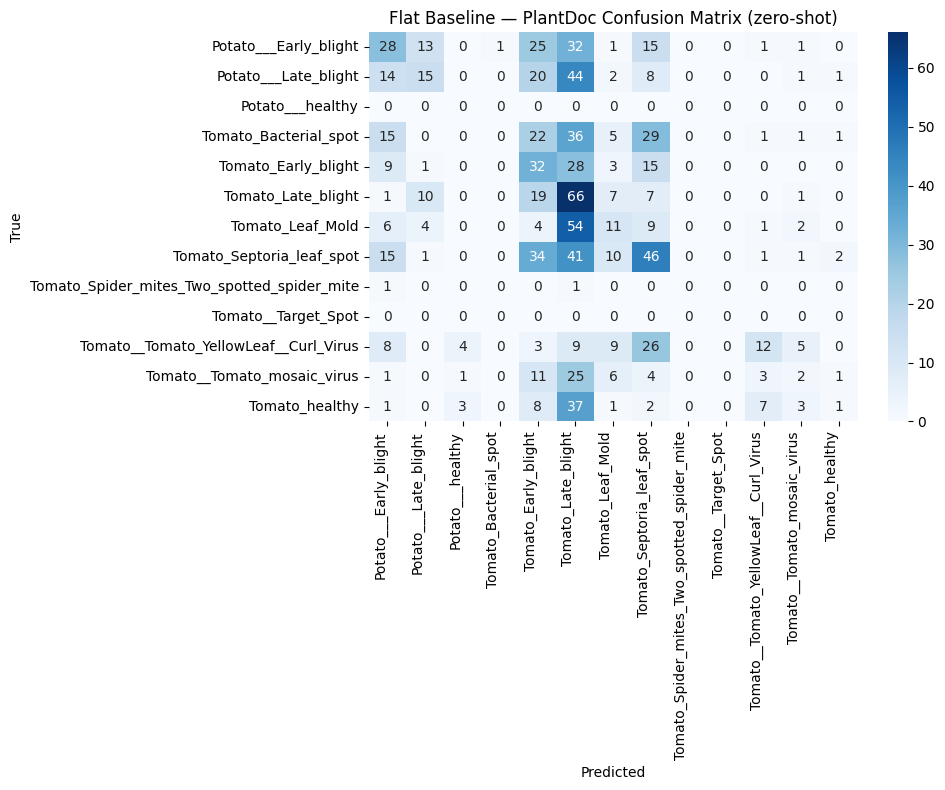

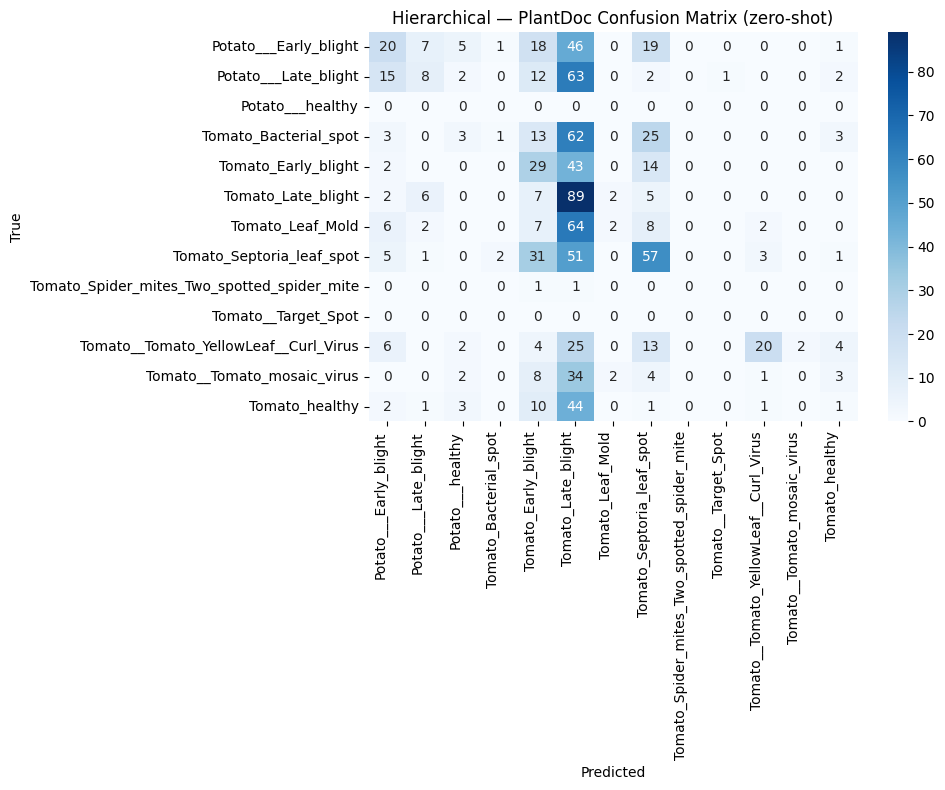

In [26]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

labels = full_class_names_sorted  # all 13 classes, fixed order for both matrices

def plot_confusion(true, pred, title, filename):
    cm = confusion_matrix(true, pred, labels=labels)
    fig, ax = plt.subplots(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=labels, yticklabels=labels, ax=ax)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('True')
    ax.set_title(title)
    plt.xticks(rotation=90, ha='right')
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.savefig(filename, dpi=150)
    plt.show()

plot_confusion(flat_true, flat_pred, "Flat Baseline — PlantDoc Confusion Matrix (zero-shot)", "/content/confusion_flat_plantdoc.png")
plot_confusion(hier_true, hier_pred, "Hierarchical — PlantDoc Confusion Matrix (zero-shot)", "/content/confusion_hier_plantdoc.png")

In [27]:
from google.colab import files
files.download("/content/confusion_flat_plantdoc.png")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [28]:
files.download("/content/confusion_hier_plantdoc.png")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>